<a href="https://colab.research.google.com/github/DontBlink113/pairs-trading/blob/main/pairs_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!pip install yfinance
!pip install lxml

In [33]:
#data block

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib as plt
import requests

START, SPLIT, END = "2010-01-01", "2022-01-01", "2025-01-01" #in-sample / out-of-sample split
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
s_and_p = pd.read_html(html)[0]
s_and_p['Symbol'] = s_and_p['Symbol'].str.replace('.', '-', regex = False)
industry = s_and_p.set_index("Symbol")["GICS Sector"].rename_axis("ticker").rename('sector')
companies = industry.index.tolist()

raw = yf.download(companies, START, END)

/tmp/ipykernel_970/4140677424.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  s_and_p = pd.read_html(html)[0]
/tmp/ipykernel_970/4140677424.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(companies, START, END)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['SNDK', 'HONA', 'FDXF', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1262322000, endDate = 1735707600")')


In [34]:
from itertools import combinations

close, volume = raw["Close"], raw["Volume"]
is_close, is_volume = close[:SPLIT], volume[:SPLIT]
os_close, os_volume = close[SPLIT:], volume[SPLIT:]

enough_history = is_close.notna().mean() >= 0.99            # ~full history in-sample
dollar_vol     = (is_close * is_volume).median()            # median $ traded / day
liquid         = dollar_vol > 2e7                           # > $20M/day


keep   = close.columns[enough_history & liquid]
close  = close[keep]
# log_px = np.log(close)
sectors = industry.reindex(keep)
print(close.shape)


candidate_pairs = []
for _, group in sectors.groupby(sectors):
  for pair in combinations(group.index, 2):
    candidate_pairs.append(pair)
print(candidate_pairs)
print(len(candidate_pairs))

(3774, 402)
[('CHTR', 'CMCSA'), ('CHTR', 'DIS'), ('CHTR', 'EA'), ('CHTR', 'GOOG'), ('CHTR', 'GOOGL'), ('CHTR', 'LYV'), ('CHTR', 'NFLX'), ('CHTR', 'OMC'), ('CHTR', 'PSKY'), ('CHTR', 'T'), ('CHTR', 'TMUS'), ('CHTR', 'TTWO'), ('CHTR', 'VZ'), ('CHTR', 'WBD'), ('CMCSA', 'DIS'), ('CMCSA', 'EA'), ('CMCSA', 'GOOG'), ('CMCSA', 'GOOGL'), ('CMCSA', 'LYV'), ('CMCSA', 'NFLX'), ('CMCSA', 'OMC'), ('CMCSA', 'PSKY'), ('CMCSA', 'T'), ('CMCSA', 'TMUS'), ('CMCSA', 'TTWO'), ('CMCSA', 'VZ'), ('CMCSA', 'WBD'), ('DIS', 'EA'), ('DIS', 'GOOG'), ('DIS', 'GOOGL'), ('DIS', 'LYV'), ('DIS', 'NFLX'), ('DIS', 'OMC'), ('DIS', 'PSKY'), ('DIS', 'T'), ('DIS', 'TMUS'), ('DIS', 'TTWO'), ('DIS', 'VZ'), ('DIS', 'WBD'), ('EA', 'GOOG'), ('EA', 'GOOGL'), ('EA', 'LYV'), ('EA', 'NFLX'), ('EA', 'OMC'), ('EA', 'PSKY'), ('EA', 'T'), ('EA', 'TMUS'), ('EA', 'TTWO'), ('EA', 'VZ'), ('EA', 'WBD'), ('GOOG', 'GOOGL'), ('GOOG', 'LYV'), ('GOOG', 'NFLX'), ('GOOG', 'OMC'), ('GOOG', 'PSKY'), ('GOOG', 'T'), ('GOOG', 'TMUS'), ('GOOG', 'TTWO'), ('G

In [35]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller


# perform cointegration test on pair, testing that
# both stocks are nonstationary, whereas a linear combination of them
# is non-stationary
# this model expects two raw series

def test_pair(asset1, asset2):

  valid = asset1.notna() & asset2.notna()
  asset1 = asset1[valid]
  asset2 = asset2[valid]


  X = np.log(asset1)
  Y = np.log(asset2)
  model = LinearRegression()
  model.fit(X.values.reshape(-1, 1), Y.values)
  beta = model.coef_[0]
  alpha = model.intercept_
  Y_hat = alpha + X.values * beta
  r = Y - Y_hat

  adf_stat, adf_pval, _, _, crit_vals, _ = adfuller(r, maxlag=1, regression='c')

  cointegrated = False
  print(adf_pval)
  if(adf_pval <= 0.05):
    cointegrated = True

  return cointegrated, alpha, beta, r, adf_pval, X, Y


  #need to fit y = bx(t) + a + e(t)

In [36]:
results = dict()
cointegrated_pairs = []

for pair in candidate_pairs:
  print("testing: ", pair[0], pair[1])

  t1 = pair[0]
  t2 = pair[1]

  cointegrated, alpha, beta, r, pval, X, Y = test_pair(close[t1], close[t2])
  results[pair] = cointegrated, alpha, beta, r, pval, X, Y
  if(cointegrated):
    cointegrated_pairs.append(pair)
print(len(cointegrated_pairs))
print(len(candidate_pairs))

Streaming output truncated to the last 5000 lines.
testing:  PCAR PH
0.0005821054981286252
testing:  PCAR PNR
0.08761968709441825
testing:  PCAR PWR
0.07497163413227843
testing:  PCAR ROK
0.23729750564823388
testing:  PCAR RSG
0.04097853631914066
testing:  PCAR RTX
0.049813354501464915
testing:  PCAR SNA
0.2512986761319965
testing:  PCAR SWK
0.6105012996456022
testing:  PCAR TDG
0.09611017304290093
testing:  PCAR TT
0.004005847018516794
testing:  PCAR TXT
0.16291544716339523
testing:  PCAR UAL
0.09751469927337164
testing:  PCAR UNP
0.35603820055490354
testing:  PCAR UPS
0.5341271098927846
testing:  PCAR URI
0.050415820155678075
testing:  PCAR VRSK
0.13295470604232484
testing:  PCAR WAB
0.23612046577309315
testing:  PCAR WM
0.11871017449317889
testing:  PH PNR
0.09842985430488393
testing:  PH PWR
0.07272815602876027
testing:  PH ROK
0.4543590246924545
testing:  PH RSG
0.02254270957438954
testing:  PH RTX
0.032147306507950286
testing:  PH SNA
0.4101187524896658
testing:  PH SWK
0.7194927

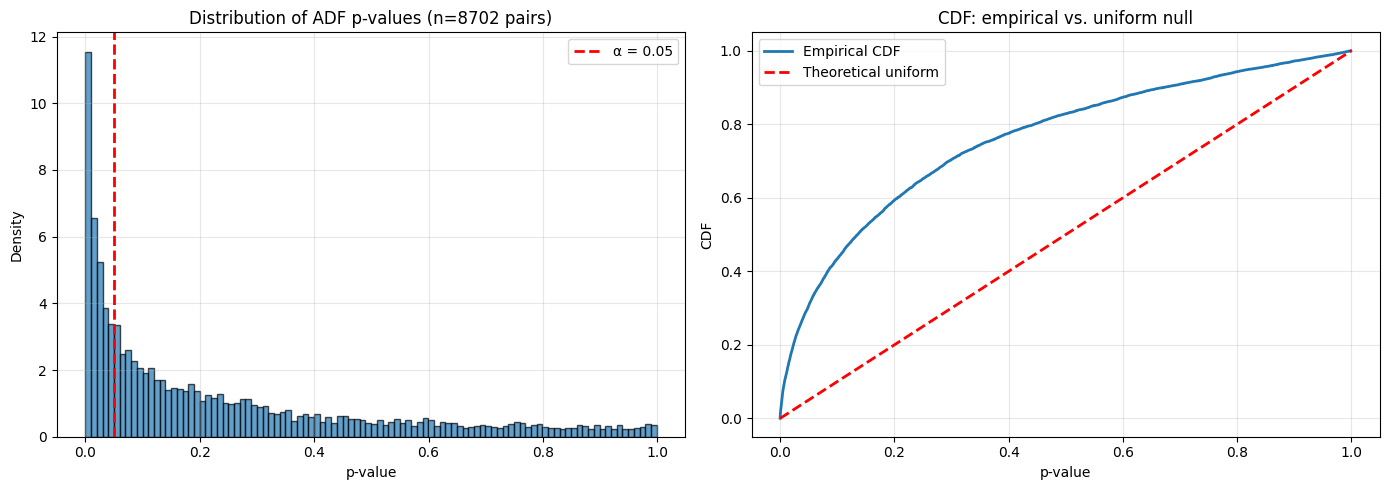

Total pairs tested: 8702
Pairs with p < 0.05: 2661
Pairs with p < 0.01: 1006
Median p-value: 0.1357
Mean p-value: 0.2389


In [37]:
# After collecting ALL p-values, plot the distribution
pvals_all = [results[pair][4] for pair in results]  # extract p-values

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(pvals_all, bins=100, edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(0.05, color='r', linestyle='--', linewidth=2, label='α = 0.05')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Distribution of ADF p-values (n={len(pvals_all)} pairs)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CDF
sorted_pvals = np.sort(pvals_all)
ecdf = np.arange(1, len(sorted_pvals) + 1) / len(sorted_pvals)
axes[1].plot(sorted_pvals, ecdf, label='Empirical CDF', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'r--', label='Theoretical uniform', linewidth=2)
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF: empirical vs. uniform null')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
print(f"Total pairs tested: {len(pvals_all)}")
print(f"Pairs with p < 0.05: {np.sum(np.array(pvals_all) < 0.05)}")
print(f"Pairs with p < 0.01: {np.sum(np.array(pvals_all) < 0.01)}")
print(f"Median p-value: {np.median(pvals_all):.4f}")
print(f"Mean p-value: {np.mean(pvals_all):.4f}")

In [38]:
# Bonferroni-corrected significance level
n_tests = len(pvals_all)
alpha_bonf = 0.05 / n_tests

cointegrated_bonf = [pair for pair in results
                     if results[pair][4] < alpha_bonf]

print(f"\nBonferroni correction:")
print(f"  α_corrected = 0.05 / {n_tests} = {alpha_bonf:.2e}")
print(f"  Pairs with p < α_corrected: {len(cointegrated_bonf)}")

# Show the top 13 by p-value
top_pairs = sorted(results.items(), key=lambda x: x[1][4])[:13]
print(f"\nTop 13 pairs by p-value:")
for pair, (cointegrated, alpha, beta, r, pval, X, Y) in top_pairs:
    print(f"  {pair[0]:6s} ↔ {pair[1]:6s}  |  β={beta:7.4f}  |  p={pval:.2e}")


Bonferroni correction:
  α_corrected = 0.05 / 8702 = 5.75e-06
  Pairs with p < α_corrected: 13

Top 13 pairs by p-value:
  HBAN   ↔ SCHW    |  β= 1.3118  |  p=9.48e-09
  HBAN   ↔ NTRS    |  β= 0.8175  |  p=7.43e-08
  LH     ↔ WAT     |  β= 1.2427  |  p=1.05e-07
  AEE    ↔ LNT     |  β= 0.9636  |  p=4.84e-07
  BAC    ↔ HBAN    |  β= 0.7538  |  p=9.25e-07
  AEE    ↔ XEL     |  β= 0.9494  |  p=1.84e-06
  HBAN   ↔ PNC     |  β= 1.0881  |  p=2.98e-06
  EIX    ↔ PPL     |  β= 0.6793  |  p=3.04e-06
  GS     ↔ MET     |  β= 0.7998  |  p=3.72e-06
  ICE    ↔ SPGI    |  β= 1.4460  |  p=4.17e-06
  BNY    ↔ HBAN    |  β= 1.1422  |  p=4.67e-06
  KEY    ↔ NTRS    |  β= 0.8665  |  p=5.14e-06
  A      ↔ LH      |  β= 0.6318  |  p=5.22e-06


In [39]:
def backtest_pair(asset1, asset2, X, Y, alpha, beta, r, os_time, close):


  z = (r - np.mean(r)) / np.std(r)

  mu = np.mean(r)
  sigma = np.std(r)

  is_close = close[:os_time]
  os_close = close[os_time:]

  os_closeX = np.log(os_close[asset1])
  os_closeY = np.log(os_close[asset2])
  os_close_Y_hat = os_closeX.values * beta + alpha
  os_close_r = os_closeY - os_close_Y_hat
  os_close_z = (os_close_r - mu) / sigma # use previous mean and std to calculate z

  THRESHOLD = 1.5

  total = np.sum((os_close_z > THRESHOLD) | (os_close_z < THRESHOLD * -1))


  NO_TRADE = 0
  SHORT_SPREAD = -1
  LONG_SPREAD = 1

  trades = []
  log_cum_ret = 0
  entry_spread_value = 0
  state = NO_TRADE
  for t, z_score in enumerate(os_close_z):
    if z_score > THRESHOLD and state != SHORT_SPREAD:
      state = SHORT_SPREAD
      entry_spread_value = os_close_r.iloc[t]
      trades.append({"entry": t, "type": "short"})
    elif z_score < -THRESHOLD and state != LONG_SPREAD:
      state = LONG_SPREAD
      entry_spread_value = os_close_r.iloc[t]
      trades.append({"entry": t, "type": "long"})
    elif abs(z_score) < 0.5 and state != NO_TRADE:
      exit_spread_value = os_close_r.iloc[t]
      if state == SHORT_SPREAD: # Closed a short position
        difference = (entry_spread_value - exit_spread_value) # Buy low, sell high for short
      elif state == LONG_SPREAD: # Closed a long position
        difference = (exit_spread_value - entry_spread_value) # Sell high, buy low for long
      log_cum_ret += difference
      print(difference)
      state = NO_TRADE


  return log_cum_ret, trades

In [40]:
'''
----------------------------------
Trading pairs with Kalman Filter.
----------------------------------

The purpose of the Kalman filter is to give dynamic estimates of the latent
variables, alpha and beta, depending on both the previous values of alpha and
beta, as well as the innovation (error): the difference in Y and Y_hat

Variables:

log_x: the log values of asset1 over time
log_y: the log values of asset2 over time
init_alpha: an initial estimate of alpha based on an in-sample analysis
init_beta: an initial estimate of beta
Q: Process noise: Covariance matrix that represents the process noise
    of alpha and beta over time. Alpha and beta become less certain as
    time goes on.
R: Measurement noise

Kalman variables and what they do

P: Covariance matrix that represents uncertainty in alpha, beta. P grows
    in the prediction step, but shrinks in the update step.

S: Estimated variance of predicted y
K: Kalman gain, represents the level of trust the model should have between
    the observed and predicted values. High K ~ more trust in observed values
'''

def trading_pairs_kalman(log_x, log_y, init_alpha, init_beta, Q, R, p_init):

  T = len(log_x)
  theta = np.array([init_beta, init_alpha])
  H = np.concatenate([log_x.reshape(-1, 1), np.ones((T, 1))], axis = 1) #shape T, 2

  P = p_init

  alphas = np.zeros(T)
  betas = np.zeros(T)
  z_scores = np.zeros(T)
  ll = 0
  for i in range(T):
    #Prediction step
    theta_hat = theta     #no natural dynamics of theta
    P_hat = P + Q     #Add process noise to P.
    y_hat = H[i, :] @ theta_hat
    S = H[i, :] @ P_hat @ H[i, :].T + R # calculate variance of predicted y

    e_t = log_y[i] - y_hat

    #Update step

    K = (P_hat @ H[i, :].T) / S #kalman gain
    theta = theta_hat + K * e_t
    P = P_hat - K.reshape(-1, 1) @ H[i, :].reshape(1, -1) @ P_hat


    #log-likelihood
    ll += -0.5 * (np.log(S) + e_t**2 / S)

    #z-score
    z_t = e_t / np.sqrt(S)

    #log values
    betas[i] = theta[0]
    alphas[i] = theta[1]
    z_scores[i] = z_t

  return alphas, betas, z_scores, ll

In [41]:
def find_kalman_hyperparams(asset1, asset2, SPLIT, close):
  #get log
  asset1_is = close[:SPLIT][asset1]
  asset2_is = close[:SPLIT][asset2]

  log_x_is = np.log(asset1_is)
  log_y_is = np.log(asset2_is)

  _, init_alpha, init_beta, r_is, _, _, _ = test_pair(asset1_is, asset2_is)
  R = np.var(r_is, ddof=2)

  Q_candidates = [np.eye(2) * q for q in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]]

  X = np.column_stack([log_x_is.values, np.ones(len(log_x_is))])
  p_init = R * np.linalg.inv(X.T @ X)


  best_q = None
  best_error = np.inf

  #Q is optimized for innovation callibration (want normalized innovation = y_hat - y / sqrt(S))
  for Q in Q_candidates:
    _, _, z, ll = trading_pairs_kalman(log_x_is.values, log_y_is.values, init_alpha, init_beta, Q, R, p_init)
    z_std = np.std(z)
    error = abs(z_std - 1.0)  # How far from normalized?
    if error < best_error:
      best_error = error
      best_q = Q

  _, _, z_is, _ = trading_pairs_kalman(log_x_is.values, log_y_is.values, init_alpha, init_beta, best_q, R, p_init)


  return init_alpha, init_beta, R, best_q, p_init, z_is


# init_alpha, init_beta, R, best_q, p_init, z_is = find_kalman_hyperparams(asset1, asset2, SPLIT, close)

In [42]:
def backtest_pair_kalman(betas, z, log_x, log_y,
                         entry=1.5, exit_=0.5):
    T = len(z)
    pos = np.zeros(T)
    for t in range(T):
        prev = pos[t-1] if t > 0 else 0
        if prev == 0:
            pos[t] = -1 if z[t] > entry else (1 if z[t] < -entry else 0)
        else:
            pos[t] = 0 if abs(z[t]) < exit_ else prev

    dly = np.diff(log_y.values)
    dlx = np.diff(log_x.values)
    pnl = pos[:-1] * (dly - betas[:-1] * dlx)

    trades = np.abs(np.diff(pos, prepend=0))[:-1]

    return pos, pnl

In [43]:
import pandas as pd
import numpy as np

def analyze_kalman(pos, pnl, betas):
    # Array lengths can be tricky, align gross notional to PnL
    gross_notional = 1 + np.abs(betas[:-1])
    daily_roc = pnl / gross_notional
    cum_roc = np.cumsum(daily_roc)
    total_roc = cum_roc[-1] if len(cum_roc) > 0 else 0

    # 1. Return Quality
    years = len(pnl) / 252.0
    annualized_roc = total_roc / years if years > 0 else 0
    volatility = np.std(daily_roc) * np.sqrt(252)
    sharpe = (np.mean(daily_roc) / np.std(daily_roc)) * np.sqrt(252) if volatility > 0 else 0

    # 2. Risk / Survivability
    peaks = np.maximum.accumulate(cum_roc)
    drawdowns = cum_roc - peaks
    max_dd = np.min(drawdowns) if len(drawdowns) > 0 else 0
    calmar = annualized_roc / abs(max_dd) if max_dd < 0 else np.inf

    # 3. Trade Tracking
    in_trade = False
    trade_pnl = 0
    trades_summary = []
    entry_idx = 0

    for i in range(len(pos)):
        if pos[i] != 0 and not in_trade:
            in_trade = True
            trade_pnl = 0
            entry_idx = i

        if in_trade:
            if i < len(pnl):
                trade_pnl += pnl[i]

            if pos[i] == 0:
                in_trade = False
                trades_summary.append({"net_pnl": trade_pnl})

    if in_trade:
        trades_summary.append({"net_pnl": trade_pnl})

    trade_df = pd.DataFrame(trades_summary)
    n_trades = len(trade_df)

    hit_rate = np.nan
    avg_win = np.nan
    avg_loss = np.nan
    fragility_warning = False

    if n_trades > 0:
        hit_rate = (trade_df['net_pnl'] > 0).mean()
        wins = trade_df[trade_df['net_pnl'] > 0]['net_pnl']
        losses = trade_df[trade_df['net_pnl'] <= 0]['net_pnl']

        avg_win = wins.mean() if not wins.empty else 0.0
        avg_loss = losses.mean() if not losses.empty else 0.0

        total_spread_pnl = trade_df['net_pnl'].sum()
        max_trade_pnl = trade_df['net_pnl'].max()
        if total_spread_pnl > 0 and (max_trade_pnl / total_spread_pnl) > 0.3:
            fragility_warning = True

    return {
        "sharpe": sharpe,
        "annualized_roc": annualized_roc,
        "annualized_volatility": volatility,
        "max_drawdown": max_dd,
        "calmar_ratio": calmar,
        "n_trades": n_trades,
        "hit_rate": hit_rate,
        "avg_win": avg_win,
        "avg_loss": avg_loss,
        "fragility_warning": fragility_warning
    }


In [44]:
import pandas as pd
import numpy as np

def analyze_static(pos, pnl, betas):
    # Array lengths can be tricky, align gross notional to PnL
    gross_notional = 1 + np.abs(betas[:-1])
    daily_roc = pnl / gross_notional
    cum_roc = np.cumsum(daily_roc)
    total_roc = cum_roc[-1] if len(cum_roc) > 0 else 0

    # 1. Return Quality
    years = len(pnl) / 252.0
    annualized_roc = total_roc / years if years > 0 else 0
    volatility = np.std(daily_roc) * np.sqrt(252)
    sharpe = (np.mean(daily_roc) / np.std(daily_roc)) * np.sqrt(252) if volatility > 0 else 0

    # 2. Risk / Survivability
    peaks = np.maximum.accumulate(cum_roc)
    drawdowns = cum_roc - peaks
    max_dd = np.min(drawdowns) if len(drawdowns) > 0 else 0
    calmar = annualized_roc / abs(max_dd) if max_dd < 0 else np.inf

    # 3. Trade Tracking
    in_trade = False
    trade_pnl = 0
    trades_summary = []
    entry_idx = 0

    for i in range(len(pos)):
        if pos[i] != 0 and not in_trade:
            in_trade = True
            trade_pnl = 0
            entry_idx = i

        if in_trade:
            if i < len(pnl):
                trade_pnl += pnl[i]

            if pos[i] == 0:
                in_trade = False
                trades_summary.append({"net_pnl": trade_pnl})

    if in_trade:
        trades_summary.append({"net_pnl": trade_pnl})

    trade_df = pd.DataFrame(trades_summary)
    n_trades = len(trade_df)

    hit_rate = np.nan
    avg_win = np.nan
    avg_loss = np.nan
    fragility_warning = False

    if n_trades > 0:
        hit_rate = (trade_df['net_pnl'] > 0).mean()
        wins = trade_df[trade_df['net_pnl'] > 0]['net_pnl']
        losses = trade_df[trade_df['net_pnl'] <= 0]['net_pnl']

        avg_win = wins.mean() if not wins.empty else 0.0
        avg_loss = losses.mean() if not losses.empty else 0.0

        total_spread_pnl = trade_df['net_pnl'].sum()
        max_trade_pnl = trade_df['net_pnl'].max()
        if total_spread_pnl > 0 and (max_trade_pnl / total_spread_pnl) > 0.3:
            fragility_warning = True

    return {
        "sharpe": sharpe,
        "annualized_roc": annualized_roc,
        "annualized_volatility": volatility,
        "max_drawdown": max_dd,
        "calmar_ratio": calmar,
        "n_trades": n_trades,
        "hit_rate": hit_rate,
        "avg_win": avg_win,
        "avg_loss": avg_loss,
        "fragility_warning": fragility_warning
    }


In [45]:
#full analysis of different pairs


coin_pairs = [("HBAN", "SCHW"),
                  ("HBAN", "NTRS"),
                  ("LH", "WAT"),
                  ("AEE", "LNT"),
                  ("BAC", "HBAN")]

static_results = dict()
kalman_results = dict()

for pair in coin_pairs:
  asset1, asset2 = pair[0], pair[1]
  _, alpha, beta, r, _, X, Y = results[pair]
  log_cum_ret, trades = backtest_pair(asset1, asset2, X, Y, alpha, beta, r, SPLIT, close)

  ret = np.exp(log_cum_ret) - 1

  os_log_x = np.log(close[asset1][SPLIT:])
  os_log_y = np.log(close[asset2][SPLIT:])
  static_spread = os_log_y - (os_log_x * beta + alpha)
  static_z = (static_spread - np.mean(r)) / np.std(r)
  static_betas = np.full(len(os_log_x), beta)
  pos_static, pnl_static = backtest_pair_kalman(static_betas, static_z.values, os_log_x, os_log_y, entry=1.5, exit_=0.5)
  static_result = analyze_static(pos_static, pnl_static, static_betas)

  init_alpha, init_beta, R, best_q, p_init, z_is = find_kalman_hyperparams(asset1, asset2, SPLIT, close)

  log_x_full = np.log(close[asset1])
  log_y_full = np.log(close[asset2])

  #run kalman algorithm on the full dataset, both in-sample and out-of-sample
  alphas, betas, z_scores, ll = trading_pairs_kalman(log_x_full.values, log_y_full.values, init_alpha, init_beta, best_q, R, p_init)

  os_split_idx = log_x_full[:SPLIT]
  split_date_idx = len(os_split_idx)

  os_kalman_alphas = alphas[split_date_idx:]
  os_kalman_betas = betas[split_date_idx:]
  os_kalman_z_scores = z_scores[split_date_idx:]
  os_log_x = log_x_full[SPLIT:]
  os_log_y = log_y_full[SPLIT:]

  pos, pnl = backtest_pair_kalman(
      os_kalman_betas, os_kalman_z_scores, os_log_x, os_log_y,
      entry=1.5, exit_=0.5
  )

  kalman_result = analyze_kalman(pos, pnl, os_kalman_betas)

  static_results[pair] = static_result
  kalman_results[pair] = kalman_result

0.23915619768638408
0.16407585590447482
0.2388237188943365
0.19248623486674576
0.2763616216450169
2.2224046889259742e-08
0.11085923855470625
0.13456566306900086
0.09405175880436811
0.09686314711469102
1.921534550381088e-08
0.16567327559227607
0.11287099105984577
0.13800355865213376
0.1029366343955358
0.11847395593811072
4.808434474231515e-06
0.05962523077495874
0.05507692797708463
0.06397315037575924
1.5677331738928178e-06
7.546659503328192e-06


In [48]:
print(static_results)
print(kalman_results)

{('HBAN', 'SCHW'): {'sharpe': np.float64(1.3876795661825414), 'annualized_roc': np.float64(0.16102775345953624), 'annualized_volatility': np.float64(0.11604102084065274), 'max_drawdown': np.float64(-0.08334417229730573), 'calmar_ratio': np.float64(1.9320817403419313), 'n_trades': 5, 'hit_rate': np.float64(1.0), 'avg_win': np.float64(0.2221807257993916), 'avg_loss': 0.0, 'fragility_warning': False}, ('HBAN', 'NTRS'): {'sharpe': np.float64(0.8529145095872525), 'annualized_roc': np.float64(0.08045219013151543), 'annualized_volatility': np.float64(0.09432620646874484), 'max_drawdown': np.float64(-0.07997458603353941), 'calmar_ratio': np.float64(1.0059719483608922), 'n_trades': 4, 'hit_rate': np.float64(1.0), 'avg_win': np.float64(0.10908495188569159), 'avg_loss': 0.0, 'fragility_warning': True}, ('LH', 'WAT'): {'sharpe': np.float64(1.2786364996588169), 'annualized_roc': np.float64(0.09532548768160959), 'annualized_volatility': np.float64(0.07455245310691946), 'max_drawdown': np.float64(-0.

In [60]:
import numpy as np
import pandas as pd

def analyze_backtest(results, min_trades=3):
    df = pd.DataFrame(results).T
    df.index = [f"{a}-{b}" for a, b in df.index]
    df = df.apply(pd.to_numeric, errors='coerce')

    traded = df[df['n_trades'] >= min_trades].copy()
    dropped = df[df['n_trades'] < min_trades]

    w = traded['n_trades']
    summary = pd.Series({
        'pairs_total':      len(df),
        'pairs_traded':     len(traded),
        'pairs_no_trades':  int((df['n_trades'] == 0).sum()),
        'total_trades':     int(df['n_trades'].sum()),
        'mean_sharpe':      traded['sharpe'].mean(),
        'median_sharpe':    traded['sharpe'].median(),
        'trade_wtd_sharpe': (traded['sharpe'] * w).sum() / w.sum(),  # weight by sample size
        'mean_ann_roc':     traded['annualized_roc'].mean(),
        'worst_drawdown':   traded['max_drawdown'].min(),
        'overall_hit_rate': traded['hit_rate'].mean(),
        'n_fragile':        int(traded['fragility_warning'].sum()),
    })
    return df.sort_values('sharpe', ascending=False), summary, dropped

table, summary, dropped = analyze_backtest(static_results)
print("static results:")
print(summary)
print(table)

table, summary, dropped = analyze_backtest(kalman_results)
print("\n")
print("kalman results:")
print(summary)
print(table)


static results:
pairs_total          5.000000
pairs_traded         4.000000
pairs_no_trades      1.000000
total_trades        17.000000
mean_sharpe          1.136239
median_sharpe        1.152181
trade_wtd_sharpe     1.165907
mean_ann_roc         0.091824
worst_drawdown      -0.083344
overall_hit_rate     1.000000
n_fragile            2.000000
dtype: float64
             sharpe  annualized_roc  annualized_volatility  max_drawdown  \
HBAN-SCHW  1.387680        0.161028               0.116041     -0.083344   
LH-WAT     1.278636        0.095325               0.074552     -0.066738   
AEE-LNT    1.025725        0.030492               0.029727     -0.022668   
HBAN-NTRS  0.852915        0.080452               0.094326     -0.079975   
BAC-HBAN   0.000000        0.000000               0.000000      0.000000   

           calmar_ratio  n_trades  hit_rate   avg_win  avg_loss  \
HBAN-SCHW      1.932082         5       1.0  0.222181       0.0   
LH-WAT         1.428358         5       1.0  0.1

In [61]:
def compare_models(model_a, model_b, name_a='Kalman', name_b='Static', min_trades=3):
    df_a, sum_a, _ = analyze_backtest(model_a, min_trades)
    df_b, sum_b, _ = analyze_backtest(model_b, min_trades)
    per_pair = pd.DataFrame({f'{name_a}_sharpe': df_a['sharpe'],
                             f'{name_b}_sharpe': df_b['sharpe']})
    per_pair['delta'] = per_pair[f'{name_a}_sharpe'] - per_pair[f'{name_b}_sharpe']
    per_pair[f'{name_a}_trades'] = df_a['n_trades'].astype(int)
    per_pair[f'{name_b}_trades'] = df_b['n_trades'].astype(int)
    agg = pd.DataFrame({name_a: sum_a, name_b: sum_b})
    agg['delta'] = agg[name_a] - agg[name_b]
    return per_pair.sort_values(f'{name_a}_sharpe', ascending=False), agg

compare_models(kalman_results, static_results)


(           Kalman_sharpe  Static_sharpe     delta  Kalman_trades  \
 LH-WAT          1.208472       1.278636 -0.070165              5   
 AEE-LNT         1.048717       1.025725  0.022992              4   
 HBAN-SCHW       0.982154       1.387680 -0.405525              5   
 HBAN-NTRS       0.898133       0.852915  0.045218              5   
 BAC-HBAN        0.000000       0.000000  0.000000              0   
 
            Static_trades  
 LH-WAT                 5  
 AEE-LNT                3  
 HBAN-SCHW              5  
 HBAN-NTRS              4  
 BAC-HBAN               0  ,
                      Kalman     Static     delta
 pairs_total        5.000000   5.000000  0.000000
 pairs_traded       4.000000   4.000000  0.000000
 pairs_no_trades    1.000000   1.000000  0.000000
 total_trades      19.000000  17.000000  2.000000
 mean_sharpe        1.034369   1.136239 -0.101870
 median_sharpe      1.015436   1.152181 -0.136745
 trade_wtd_sharpe   1.033614   1.165907 -0.132293
 mean_ann_roc  